# Final Presentation


**Authors:** TU/e EES Group (Michiel, Simon, Cas, Martijn, Mikhail)

This notebook demonstrates the capabilities of our `power-system-simulation` package. We will load a large-scale low-voltage network and perform three key analytical workflows:
1. **EV Penetration Simulation:** Analyzing the stress of home charging on the grid.
2. **Transformer Tap Optimization:** Automatically correcting voltage drops.
3. **N-1 Contingency Analysis:** Determining safe alternative routing during a cable failure.

## Assignment 1 Graph Processing
At the core, the grid is mapped as a mathematical graph, where busses, sources and households are nodes, while cables and transformers are edges. 
As backbone of this network, the `GraphProcesser` class is made utilizing the `networkx` Python library. Numerous unique error classes were also defined to help with troubleshooting. The input consist of only list which contain the graph structure. 
This class contains 2 different functions, which will be used later:
* `find_downstream_vertices(edge_id)`- Given an edge id, return all the vertices which are in the downstream of the edge,with respect to the source vertex. Including the downstream vertex of the edge itself
* `find_alternative_edges(edge_id)`- When an edge is going to be disabled, find an edge which will make the graph valid again


### Demonstrating the Graph Algorithms (Assignment 1 Scenario)

To prove that our graph algorithms work flawlessly, we will initialize the `GraphProcessor` using the exact test scenario provided in the Assignment 1 documentation. 

**The Grid Layout:**
* **Node 0** is the power source.
* **Edges 1, 3, 5, and 9** are active power lines.
* **Edges 7 and 8** are open switches (disabled lines) acting as backup bridges.

```text
vertex_0 (source) --edge_1(enabled)-- vertex_2 --edge_9(enabled)-- vertex_10
         |                               |
         |                               edge_7(disabled)
         |                               |
         -----------edge_3(enabled)-- vertex_4
         |                               |
         |                               edge_8(disabled)
         |                               |
         -----------edge_5(enabled)-- vertex_6

In [ ]:
from power_system_simulation.graph_processing import GraphProcessor

vertex_ids = [0, 2, 4, 6, 10]
edge_ids = [1, 3, 5, 7, 8, 9]
edge_vertex_pairs = [(0, 2), (0, 4), (0, 6), (2, 4), (4, 6), (2, 10)]
edge_enabled = [True, True, True, False, False, True] 
source_id = 0

processor = GraphProcessor(
    vertex_ids=vertex_ids,
    edge_ids=edge_ids,
    edge_vertex_id_pairs=edge_vertex_pairs,
    edge_enabled=edge_enabled,
    source_vertex_id=source_id
)

print("Downstream vertices of edge 1:", processor.find_downstream_vertices(1))
print("Alternative downstream vertices of edge 1:", processor.find_alternative_edges(1))

Downstream vertices of edge 1: [2, 10]
Alternative downstream vertices of edge 1: [7]


## Assignment 2 Power Grid Model
In this assignment, the power grid calculation module was developed with the expected functionalities from the exercise. The input data consisted of the following 3 inputs:
* `PGM power grid`
* `Active Load Profile` - Table containing the load profile per timestep per node
* `Reactive Load Profile` - Table containing the reactive load profile per timestep per node

The following functionalities are considerd in this class:
### Functionalities

We expect that you implement the following functionalities, including some error handling.
You need to test the error handling which is explicitely listed.

* Construct PGM using the input data.
  * Raise (passthrough the `ValidationException`) error if the input data is invalid.
* Create a PGM batch update dataset with the active and reactive load profiles.
  * Raise error if the two profiles does not have matching timestamps and/or load ids.
* Run time-series (batch) power flow calculation.
  * Raise (passthrough the `ValidationException`) error if the batch dataset is invalid.
* Aggregate the power flow results in the following two tables:
  * A table with each row representing a timestamp, with the following columns:
    * Timestamp (index column)
    * Maximum p.u. voltage of all the nodes for this timestamp
    * The node ID with the maximum p.u. voltage
    * Minimum p.u. voltage of all the nodes for this timestamp
    * The node ID with the minimum p.u. voltage
  * A table with each row representing a line, with the following columns:
    * Line ID (index column)
    * Energy loss of the line across the timeline in kWh (pay attention to unit conversions!)
      * You need to use the descrete numerical integral with [Trapezoidal rule](https://en.wikipedia.org/wiki/Trapezoidal_rule).
    * Maximum loading in p.u. of the line across the whole timeline
    * Timestamp of this maximum loading moment
    * Minimum loading in p.u. of the line across the whole timeline
    * Timestamp of this minimum loading moment

In [9]:
from power_system_simulation.power_grid_calculator import GridModel
import matplotlib.pyplot as plt

FILE_PATH_VALID_INPUT = "../tests/PGM_TestData/input"

model = GridModel(
        power_grid_model_path=FILE_PATH_VALID_INPUT + "/input_network_data.json",
        active_load_profiles_path=FILE_PATH_VALID_INPUT + "/active_power_profile.parquet",
        reactive_load_profiles_path=FILE_PATH_VALID_INPUT + "/reactive_power_profile.parquet",
    )

output_row_per_timestamp, output_row_per_line = model.AggregateResults()

print("\n--- Aggregated Node Results (First 5 Timestamps) ---")
display(output_row_per_timestamp.head())

print("\n--- Aggregated Line Results (Top 5 Most Stressed Lines) ---")
display(output_row_per_line.sort_values(by="Max_Loading", ascending=False).head())




--- Aggregated Node Results (First 5 Timestamps) ---


,Max_Voltage,Max_Voltage_Node,Min_Voltage,Min_Voltage_Node
Timestamp,,,,
2024-01-01 00:00:00,1.004847,1.0,1.003450,3.0
2024-01-01 01:00:00,1.012053,3.0,1.007998,1.0
2024-01-01 02:00:00,0.997474,1.0,0.984365,4.0
2024-01-01 03:00:00,1.006557,4.0,1.005190,1.0
2024-01-01 04:00:00,1.011007,4.0,1.005877,1.0



--- Aggregated Line Results (Top 5 Most Stressed Lines) ---


,Total_Loss,Max_Loading,Max_Loading_Timestamp,Min_Loading,Min_Loading_Timestamp
Line_ID,,,,,
5,63.294763,0.149830,2024-01-01 06:00:00,0.063798,2024-01-01 03:00:00
6,36.775143,0.111039,2024-01-01 05:00:00,0.037184,2024-01-01 00:00:00
7,14.872359,0.071700,2024-01-01 02:00:00,0.020380,2024-01-01 01:00:00


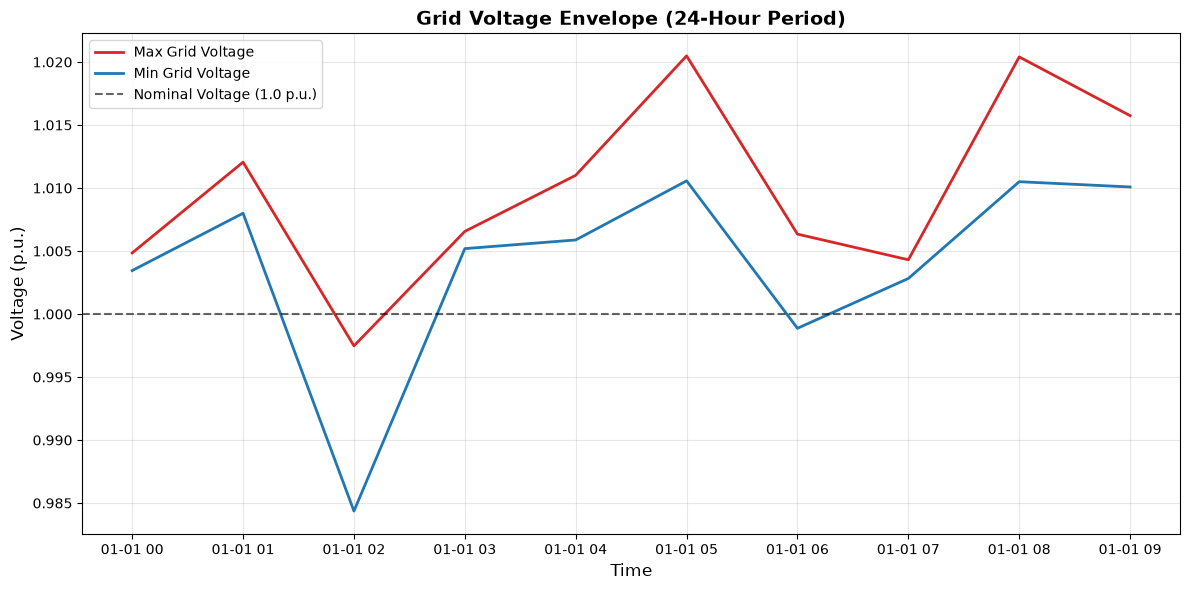

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(output_row_per_timestamp.index, output_row_per_timestamp["Max_Voltage"], label="Max Grid Voltage", color="#d62728", linewidth=2)
plt.plot(output_row_per_timestamp.index, output_row_per_timestamp["Min_Voltage"], label="Min Grid Voltage", color="#1f77b4", linewidth=2)


plt.axhline(1.0, color="black", linestyle="--", alpha=0.6, label="Nominal Voltage (1.0 p.u.)")


plt.title("Grid Voltage Envelope (24-Hour Period)", fontsize=14, fontweight="bold")
plt.xlabel("Time", fontsize=12)
plt.ylabel("Voltage (p.u.)", fontsize=12)
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## Assignment 3
The last assignment concerns the overal packages which contain the final grid analytics function, which will be introduced later
## Input data Requirments for LvGridAnalytics

To perform grid simulations, LVGridAnalytrics requires multiple different types of input variables which will be laid out.

### 1. The phystical Grid topology
**Parameter:** `grid_path`
* **Format** A `.json` file
* **Description** Contains full LVGridTopology, must contain one source and one transformer. Must be fully connected and must be acyclic

### 2. Meta Data
**Parameter:** `meta_data`
* **Format** A `.json` file
* **Description** File must contains numerous variables like busbar number, feeder line numbers, transformer number, etc.

### 3. Active and Reactive load profiles
**Parameter:** `active_load_profile_path` & `reactive_load_profile_path`
* **Format** A `.parquet` file
* **Description** File contains Timestamps and the associate load with the component ID. Both active and reactive profiles must match in timestamps and IDs

### 4. Ev profile pool
**Parameter:** `ev_profile_path` (String)
* **Format:** A `.parquet` file
* **Description:** Pool of EV charging profiles

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from power_system_simulation.lv_grid_analytics import LVGridAnalytics

DATA_DIR = "../tests/big_network/big_network/input/"
#DATA_DIR = "../tests/small_network/"
analytics = LVGridAnalytics(
    grid_path=DATA_DIR + "input_network_data.json",
    meta_data=DATA_DIR + "meta_data.json",
    active_load_profile_path=DATA_DIR + "active_power_profile.parquet",
    reactive_load_profile_path=DATA_DIR + "reactive_power_profile.parquet",
    ev_profile_path=DATA_DIR + "ev_active_power_profile.parquet"
)

print("Grid successfully loaded, validated, and fully connected.")

Grid successfully loaded, validated, and fully connected.


## Validation data (END)


In [21]:
vertex_ids = [1, 2, 2]  # Duplicate vertex ID
edge_ids = [1, 2]
edge_vertex_id_pairs = [(1, 2), (2, 3)]
edge_enabled = [True, True]
source_vertex_id = 1

try:
    processor = GraphProcessor(
        vertex_ids=vertex_ids,
        edge_ids=edge_ids,
        edge_vertex_id_pairs=edge_vertex_pairs,
        edge_enabled=edge_enabled,
        source_vertex_id=source_id
    )
except Exception as e:
    print(f"Validation Error: {e}")

Validation Error: vertex_ids should be unique.


In [22]:
vertex_ids = [1, 2, 3]
edge_ids = [1, 2]
edge_vertex_id_pairs = [(1, 2), (2, 3)]
edge_enabled = [True]  # Length does not match edge_ids
source_vertex_id = 1

try:
    processor = GraphProcessor(
        vertex_ids=vertex_ids,
        edge_ids=edge_ids,
        edge_vertex_id_pairs=edge_vertex_pairs,
        edge_enabled=edge_enabled,
        source_vertex_id=source_id
    )
except Exception as e:
    print(f"Validation Error: {e}")

Validation Error: edge_vertex_id_pairs should have the same length as edge_ids.


In [23]:
FILE_PATH_FALSE_INPUT = "../tests/PGM_TestData/false_input"

try:
    model = GridModel(
        power_grid_model_path=FILE_PATH_FALSE_INPUT + "/input_network_data.json",
        active_load_profiles_path=FILE_PATH_FALSE_INPUT + "/active_power_profile.parquet",
        reactive_load_profiles_path=FILE_PATH_FALSE_INPUT + "/reactive_power_profile.parquet",
    )
except Exception as e:
    print(f"Validation Error: {e}")

Validation Error: There was a internal error in the power grid model.


In [24]:
try:
    LVGridAnalytics(
        grid_path=DATA_DIR + "/input_network_data.json",
        feeder_line_ids=[16, 20],
        active_load_profile_path=DATA_DIR + "/active_power_profile.parquet",
        reactive_load_profile_path=DATA_DIR + "/ev_active_power_profile.parquet",
        ev_profile_path=DATA_DIR + "/ev_active_power_profile.parquet",
    )
except Exception as e:
    print(f"Validation Error: {e}")


Validation Error: Active and reactive load profiles have mismatched Load IDs.


In [25]:
try:
    faulty_analytics = LVGridAnalytics(
        grid_path=DATA_DIR + "/input_network_data.json",
        feeder_line_ids=[99999],
        active_load_profile_path=DATA_DIR + "/active_power_profile.parquet",
        reactive_load_profile_path=DATA_DIR + "/reactive_power_profile.parquet",
        ev_profile_path=DATA_DIR + "/ev_active_power_profile.parquet",
    )
    faulty_analytics.validate_inputs()
except Exception as e:
    print(f"Validation Error: {e}")


Validation Error: Feeder line ID 99999 is not valid.


# Collabartion and Use of AI

- Weekly group meetings
   * Progress, approach, obstacles
   * Discussions via Whatsapp and Github
   * Meetings during Q&A sessions

- Coach meetings
    * Before assignment 2
    * Before assignment 3

- Major code contributions were reviewed and discussed before being merged


## Example Pull Request Review

![Review](images/PullDiscussion.png)

Figure 1: Example discussion and review process before merging code into a branch.

![Approved](images/ApprovedChanges.png)


## Use of AI

AI was used to assist with implementation details and debugging.

Example applications:
- Understanding Power Grid Model APIs
- Simplifying Python code
- Explaining exceptions and error messages

All AI-generated/adjusted code was reviewed, adapted, and validated by the team before inclusion in the project.

# Downside of AI
- Not 100% reliable
- autofill


## Conclusion

- Smooth collabaration
- Although we only had 2 coach meetings, we think this was sufficient since we did not get stuck on certain parts of the project such that the coach had to step in.
- AI can be helpfull, but does not always push you in the right direction